In [46]:
import os
os.getcwd()




'C:\\Users\\Mohsin\\Ebay Project'

In [47]:
os.listdir()


['.ipynb_checkpoints', 'eBay (1).csv', 'Untitled.ipynb']

# Task 1: Data Cleaning and Preparation

In [48]:
import pandas as pd
import numpy as np
df = pd.read_csv("eBay (1).csv")   


In [49]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

## Remove duplicate or inconsistent survey responses

In [50]:
# drop exact duplicate rows
df = df.drop_duplicates()

# if the same transaction id appears multiple times, keep first occurrence
df = df.drop_duplicates(subset="transaction", keep="first")


In [51]:
df = df[(df["age"] >= 5) & (df["age"] <= 100)]


## Standardize categorical / numerical entries

In [52]:
freq_order = [
    "Never",
    "Rarely",
    "Less than once a month",
    "Once a month",
    "Few times a month",
    "Once a week",
    "Few times a week",
    "Multiple times a week",
    "Multiple times a day"
]

freq_cols = [
    "Purchase_Frequency",
    "Browsing_Frequency",
    "Cart_Completion_Frequency",
    "Saveforlater_Frequency"
]

for col in freq_cols:
    df[col] = pd.Categorical(df[col], categories=freq_order, ordered=True)


## Standardize gender and recommendation‑type answers

In [53]:
gender_map = {
    "Male": "Male",
    "Female": "Female",
    "Others": "Other",
    "Prefer not to say": "Prefer not to say"
}
df["Gender"] = df["Gender"].map(gender_map)

# yes/no/maybe style columns – make everything consistent lower case
yn_cols = ["Add_to_Cart_Browsing", "Review_Left"]
for col in yn_cols:
    df[col] = df[col].str.strip().str.title()   # e.g. "yes" → "Yes"


## Handle missing values and inconsistent

In [54]:
# strip spaces from all string columns
obj_cols = df.select_dtypes(include="object").columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

# convert common placeholders to proper NaN
missing_placeholders = ["nan", "NaN", ".", "Nil", "Nothing"]
for col in obj_cols:
    df[col] = df[col].replace(missing_placeholders, np.nan)

# clean Product_Search_Method
df["Product_Search_Method"] = df["Product_Search_Method"].str.lower()

method_map = {
    "keyword": "Keyword search",
    "filter": "Filter",
    "categories": "Browse categories",
    "others": "Other"
}
df["Product_Search_Method"] = df["Product_Search_Method"].map(method_map)


In [55]:
df["Product_Search_Method"].value_counts(dropna=False)


Product_Search_Method
Keyword search       172
Other                159
NaN                  157
Browse categories    156
Filter               135
Name: count, dtype: int64

## Rename duplicate or misformatted columns

In [56]:
# remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

# if this creates duplicate column names, keep first occurrence
df = df.loc[:, ~df.columns.duplicated()]


## Convert rating columns to numeric so you can do analysis and clustering.

In [57]:
# columns where users gave 1-5 ratings
rating_cols = [
    "Customer_Reviews_Importance",
    "Shopping_Satisfaction",
    "Service_Appreciation",
    "Rating_Accuracy",
    "Recommendation_Helpfulness",
    "Review_Reliability",
    "Review_Helpfulness"
]

# convert rating columns to proper numeric (non-numeric → NaN)
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# fill missing ratings with median so models don't break later
for col in rating_cols:
    df[col] = df[col].fillna(df[col].median())


# Task 2: Descriptive Behavior Analysis

## Summarize customer demographics (age, gender distribution)

In [58]:
# AGE SUMMARY
print("AGE SUMMARY STATISTICS")
print("-" * 40)

age_summary = df["age"].describe()
print(age_summary)

# Create age groups
age_bins = [0, 17, 24, 34, 44, 54, 64, 120]
age_labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["AgeGroup"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=True)

print("\nAge group counts:")
age_group_counts = df["AgeGroup"].value_counts().sort_index()
print(age_group_counts)


AGE SUMMARY STATISTICS
----------------------------------------
count    779.000000
mean      36.596919
std       18.060219
min        5.000000
25%       20.000000
50%       38.000000
75%       52.000000
max       67.000000
Name: age, dtype: float64

Age group counts:
AgeGroup
<18      158
18-24     86
25-34    103
35-44    132
45-54    141
55-64    128
65+       31
Name: count, dtype: int64


In [59]:
# GENDER DISTRIBUTION
print("\nGENDER DISTRIBUTION")
print("-" * 40)

gender_counts = df["Gender"].value_counts()
gender_percent = df["Gender"].value_counts(normalize=True) * 100

print("Counts:")
print(gender_counts)

print("\nPercentages (%):")
print(gender_percent.round(2))



GENDER DISTRIBUTION
----------------------------------------
Counts:
Gender
Other                205
Prefer not to say    199
Female               192
Male                 183
Name: count, dtype: int64

Percentages (%):
Gender
Other                26.32
Prefer not to say    25.55
Female               24.65
Male                 23.49
Name: proportion, dtype: float64


## Analyze overall purchase frequency and most popular product categories

In [60]:
# PURCHASE FREQUENCY
print("\nPURCHASE FREQUENCY DISTRIBUTION")
print("-" * 40)

purchase_freq_counts = df["Purchase_Frequency"].value_counts().sort_index()
purchase_freq_percent = df["Purchase_Frequency"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(purchase_freq_counts)

print("\nPercentages (%):")
print(purchase_freq_percent.round(2))



PURCHASE FREQUENCY DISTRIBUTION
----------------------------------------
Counts:
Purchase_Frequency
Never                       0
Rarely                      0
Less than once a month    167
Once a month              159
Few times a month         170
Once a week               140
Few times a week            0
Multiple times a week     143
Multiple times a day        0
Name: count, dtype: int64

Percentages (%):
Purchase_Frequency
Never                      0.00
Rarely                     0.00
Less than once a month    21.44
Once a month              20.41
Few times a month         21.82
Once a week               17.97
Few times a week           0.00
Multiple times a week     18.36
Multiple times a day       0.00
Name: proportion, dtype: float64


In [61]:
# POPULAR PRODUCT CATEGORIES
print("\nTOP PRODUCT CATEGORIES")
print("-" * 40)

# Split semicolon-separated categories and explode
cat_series = df["Purchase_Categories"].str.split(";", expand=False)
cat_exploded = cat_series.explode().str.strip()

top_categories = cat_exploded.value_counts()

print("Top 15 categories:")
print(top_categories.head(15))



TOP PRODUCT CATEGORIES
----------------------------------------
Top 15 categories:
Purchase_Categories
Clothing and Fashion          438
Home and Kitchen              409
Beauty and Personal Care      408
others                        379
Groceries and Gourmet Food    357
Name: count, dtype: int64


In [62]:
# BROWSING / SEARCH METHODS
print("\nPRODUCT SEARCH / BROWSING METHODS")
print("-" * 40)

search_method_counts = df["Product_Search_Method"].value_counts(dropna=False)
search_method_percent = df["Product_Search_Method"].value_counts(normalize=True, dropna=False) * 100

print("Counts (including NaN):")
print(search_method_counts)

print("\nPercentages (%):")
print(search_method_percent.round(2))



PRODUCT SEARCH / BROWSING METHODS
----------------------------------------
Counts (including NaN):
Product_Search_Method
Keyword search       172
Other                159
NaN                  157
Browse categories    156
Filter               135
Name: count, dtype: int64

Percentages (%):
Product_Search_Method
Keyword search       22.08
Other                20.41
NaN                  20.15
Browse categories    20.03
Filter               17.33
Name: proportion, dtype: float64


In [63]:
# CART ABANDONMENT FACTORS
print("\nCART ABANDONMENT FACTORS")
print("-" * 40)

abandonment_counts = df["Cart_Abandonment_Factors"].str.strip().value_counts()
abandonment_percent = df["Cart_Abandonment_Factors"].str.strip().value_counts(normalize=True) * 100

print("Top 10 reasons (counts):")
print(abandonment_counts.head(10))

print("\nTop 10 reasons (percentages):")
print(abandonment_percent.head(10).round(2))



CART ABANDONMENT FACTORS
----------------------------------------
Top 10 reasons (counts):
Cart_Abandonment_Factors
High shipping costs                           204
Changed my mind or no longer need the item    197
others                                        196
Found a better price elsewhere                182
Name: count, dtype: int64

Top 10 reasons (percentages):
Cart_Abandonment_Factors
High shipping costs                           26.19
Changed my mind or no longer need the item    25.29
others                                        25.16
Found a better price elsewhere                23.36
Name: proportion, dtype: float64


## Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy

In [64]:
# SATISFACTION & RATINGS
print("\nSATISFACTION, RECOMMENDATION HELPFULNESS, RATING ACCURACY")
print("-" * 60)

rating_cols = [
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness",
    "Rating_Accuracy",
]

# Ensure numeric
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

metrics_summary = df[rating_cols].agg(["mean", "median", "min", "max", "std"])
print(metrics_summary)



SATISFACTION, RECOMMENDATION HELPFULNESS, RATING ACCURACY
------------------------------------------------------------
        Shopping_Satisfaction  Recommendation_Helpfulness  Rating_Accuracy
mean                 2.858793                         NaN         3.077022
median               3.000000                         NaN         3.000000
min                  1.000000                         NaN         1.000000
max                  5.000000                         NaN         5.000000
std                  1.427092                         NaN         1.416656


## Generate summary statistics and visualizations for key behavioral variables

In [65]:
# SUMMARY STATISTICS FOR KEY BEHAVIOURAL VARIABLES
print("\nSUMMARY STATISTICS (BEHAVIOURAL VARIABLES)")
print("-" * 60)

behaviour_cols = [
    "Customer_Reviews_Importance",
    "Shopping_Satisfaction",
    "Rating_Accuracy",
    "Recommendation_Helpfulness",
]

# Ensure numeric
for col in behaviour_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

behaviour_summary = df[behaviour_cols].describe()
print(behaviour_summary)



SUMMARY STATISTICS (BEHAVIOURAL VARIABLES)
------------------------------------------------------------
       Customer_Reviews_Importance  Shopping_Satisfaction  Rating_Accuracy  \
count                   779.000000             779.000000       779.000000   
mean                      3.001284               2.858793         3.077022   
std                       1.391767               1.427092         1.416656   
min                       1.000000               1.000000         1.000000   
25%                       2.000000               2.000000         2.000000   
50%                       3.000000               3.000000         3.000000   
75%                       4.000000               4.000000         4.000000   
max                       5.000000               5.000000         5.000000   

       Recommendation_Helpfulness  
count                         0.0  
mean                          NaN  
std                           NaN  
min                           NaN  
25%         

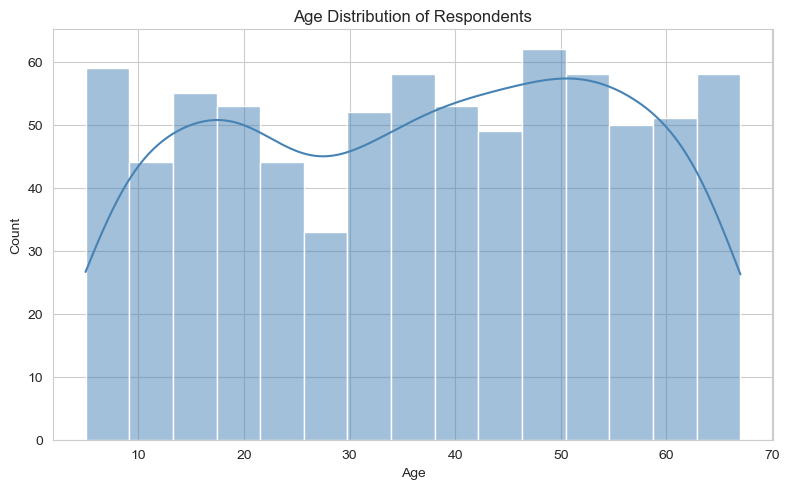

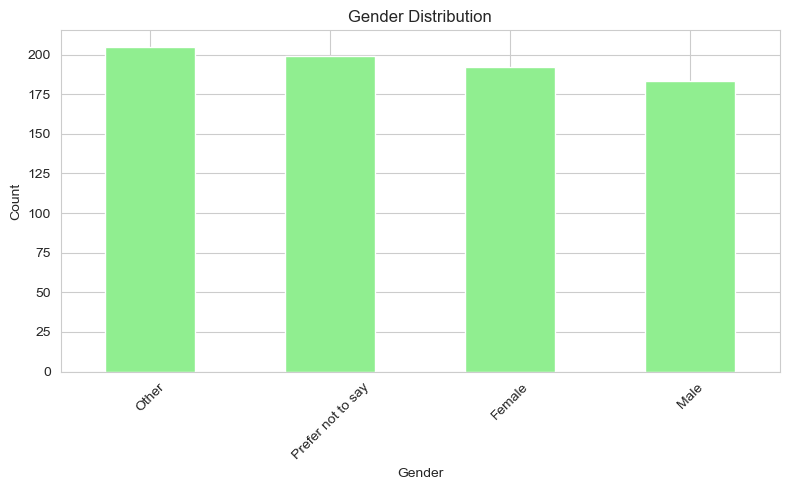

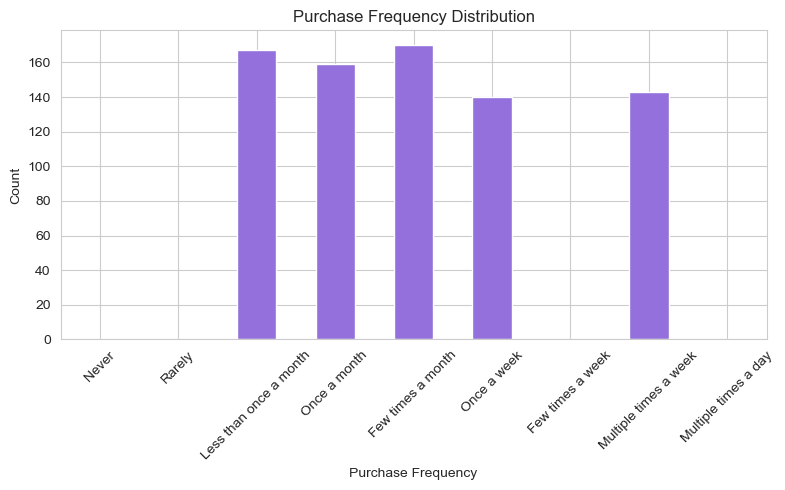

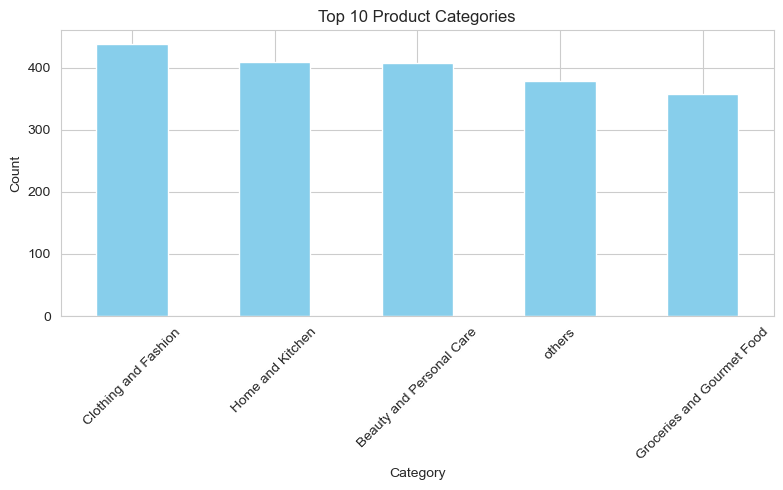

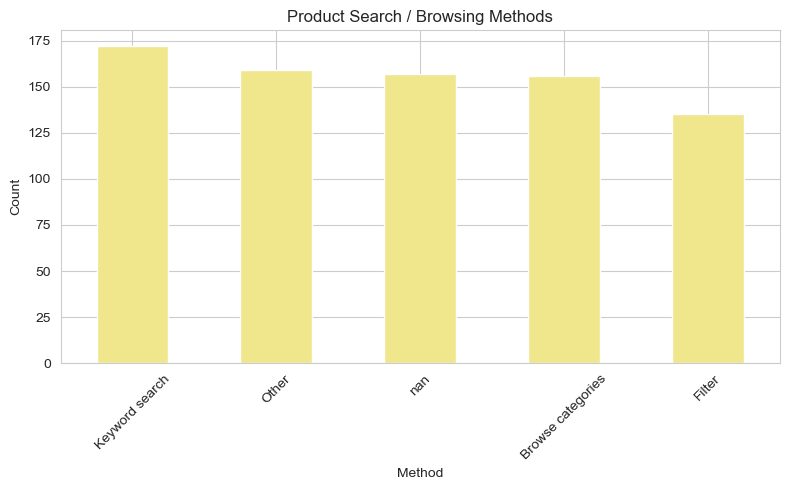

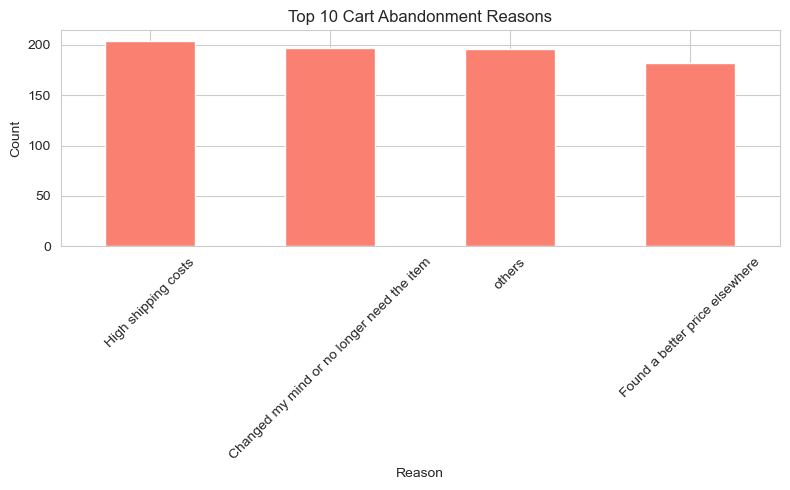

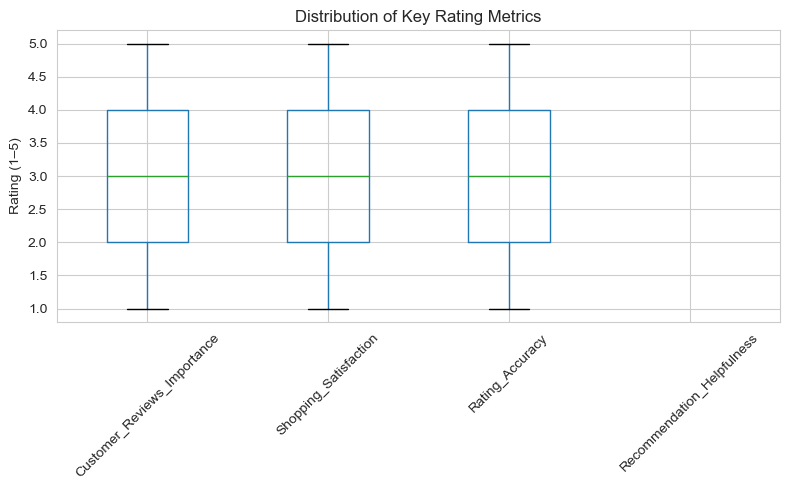

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1) Age distribution histogram
plt.figure()
sns.histplot(df["age"], bins=15, kde=True, color="steelblue")
plt.title("Age Distribution of Respondents")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Gender distribution bar chart
plt.figure()
gender_counts.plot(kind="bar", color="lightgreen")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Purchase frequency bar chart
plt.figure()
purchase_freq_counts.plot(kind="bar", color="mediumpurple")
plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4) Top 10 product categories bar chart
plt.figure()
top_categories.head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Search methods bar chart
plt.figure()
search_method_counts.plot(kind="bar", color="khaki")
plt.title("Product Search / Browsing Methods")
plt.xlabel("Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6) Top 10 cart abandonment reasons bar chart
plt.figure()
abandonment_counts.head(10).plot(kind="bar", color="salmon")
plt.title("Top 10 Cart Abandonment Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7) Boxplot of key rating metrics
plt.figure()
df[behaviour_cols].boxplot()
plt.title("Distribution of Key Rating Metrics")
plt.ylabel("Rating (1–5)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Task 3: Customer Segmentation and Profiling

## Segment customers based on purchase frequency and shopping satisfaction levels.

In [67]:
# Map ordered purchase frequency to a numeric score
freq_score_map = {
    "Never": 0,
    "Rarely": 1,
    "Less than once a month": 2,
    "Once a month": 3,
    "Few times a month": 4,
    "Once a week": 5,
    "Few times a week": 6,
    "Multiple times a week": 7,
    "Multiple times a day": 8,
}

df["Purchase_Freq_Score"] = df["Purchase_Frequency"].map(freq_score_map)
df["Purchase_Freq_Score"].head()


0    7
1    7
2    3
3    3
4    5
Name: Purchase_Freq_Score, dtype: category
Categories (9, int64): [0 < 1 < 2 < 3 ... 5 < 6 < 7 < 8]

In [68]:
# Define 3 levels based on the score
def label_frequency(score):
    if score <= 2:        # Never / Rarely / Less than once a month
        return "Low"
    elif score <= 4:      # Once a month / Few times a month
        return "Medium"
    else:                 # Once a week and above
        return "High"

df["Freq_Level"] = df["Purchase_Freq_Score"].apply(label_frequency)

df["Freq_Level"].value_counts()


Freq_Level
Medium    329
High      283
Low       167
Name: count, dtype: int64

In [69]:
# Shopping_Satisfaction is already 1–5
def label_satisfaction(x):
    if x <= 2:
        return "Low"
    elif x == 3:
        return "Medium"
    else:   # 4 or 5
        return "High"

df["Sat_Level"] = df["Shopping_Satisfaction"].apply(label_satisfaction)

df["Sat_Level"].value_counts()


Sat_Level
Low       344
High      281
Medium    154
Name: count, dtype: int64

## Create profiles: Frequent Buyers, Occasional Shoppers, At-Risk Customers

In [70]:
def assign_segment(row):
    # Frequent Buyers: High frequency & High satisfaction
    if row["Freq_Level"] == "High" and row["Sat_Level"] == "High":
        return "Frequent Buyers"
    
    # Occasional Shoppers: Medium frequency & Medium satisfaction
    if row["Freq_Level"] == "Medium" and row["Sat_Level"] in ["Medium", "High"]:
        return "Occasional Shoppers"
    
    # At-Risk Customers: Low satisfaction or frequent cart abandonment
    # (here we use Low satisfaction OR 'Often/Always' abandoning)
    if row["Sat_Level"] == "Low":
        return "At-Risk Customers"
    
    # Default bucket for everyone else
    return "Other"

df["Customer_Segment"] = df.apply(assign_segment, axis=1)

df["Customer_Segment"].value_counts()


Customer_Segment
At-Risk Customers      344
Occasional Shoppers    186
Other                  146
Frequent Buyers        103
Name: count, dtype: int64

## Analyze demographic / behavioral differences across segments

In [71]:
# Ensure numeric types for aggregation
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["Purchase_Freq_Score"] = pd.to_numeric(df["Purchase_Freq_Score"], errors="coerce")
df["Shopping_Satisfaction"] = pd.to_numeric(df["Shopping_Satisfaction"], errors="coerce")


In [72]:
# Segment counts
segment_counts = df["Customer_Segment"].value_counts()
print("Segment counts:")
print(segment_counts)

# Age by segment
age_by_segment = df.groupby("Customer_Segment")["age"].agg(["mean", "median", "min", "max", "count"])
print("\nAge stats by segment:")
print(age_by_segment)

# Purchase frequency score by segment
freq_by_segment = df.groupby("Customer_Segment")["Purchase_Freq_Score"].agg(["mean", "median"])
print("\nPurchase frequency score by segment:")
print(freq_by_segment)

# Satisfaction by segment
sat_by_segment = df.groupby("Customer_Segment")["Shopping_Satisfaction"].agg(["mean", "median"])
print("\nShopping satisfaction by segment:")
print(sat_by_segment)


Segment counts:
Customer_Segment
At-Risk Customers      344
Occasional Shoppers    186
Other                  146
Frequent Buyers        103
Name: count, dtype: int64

Age stats by segment:
                          mean  median  min  max  count
Customer_Segment                                       
At-Risk Customers    37.558140    39.0    5   67    344
Frequent Buyers      35.126214    36.0    5   67    103
Occasional Shoppers  35.150538    36.5    5   67    186
Other                37.212329    39.0    5   67    146

Purchase frequency score by segment:
                         mean  median
Customer_Segment                     
At-Risk Customers    4.116279     4.0
Frequent Buyers      6.087379     7.0
Occasional Shoppers  3.489247     3.0
Other                3.424658     2.0

Shopping satisfaction by segment:
                         mean  median
Customer_Segment                     
At-Risk Customers    1.459302     1.0
Frequent Buyers      4.475728     4.0
Occasional Shoppers  

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    "Purchase_Freq_Score",
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy",
]

X = df[cluster_features].copy()
for col in cluster_features:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype("float64")

print("NaNs per column after to_numeric:")
print(X.isna().sum(), "\n")

X_no_na = X.dropna()
print("Original rows:", len(df))
print("Rows after dropping NaNs:", len(X_no_na))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_na)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df.loc[X_no_na.index, "Behavior_Cluster"] = clusters
print("\nCluster value counts:")
print(df["Behavior_Cluster"].value_counts(dropna=False))


NaNs per column after to_numeric:
Purchase_Freq_Score            0
Shopping_Satisfaction          0
Customer_Reviews_Importance    0
Rating_Accuracy                0
dtype: int64 

Original rows: 779
Rows after dropping NaNs: 779


C:\Users\Mohsin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



Cluster value counts:
Behavior_Cluster
1.0    298
2.0    264
0.0    217
Name: count, dtype: int64


Gender distribution by segment

In [74]:
gender_segment = pd.crosstab(df["Customer_Segment"], df["Gender"], normalize="index") * 100
print("\nGender % within each segment:")
print(gender_segment.round(1))



Gender % within each segment:
Gender               Female  Male  Other  Prefer not to say
Customer_Segment                                           
At-Risk Customers      26.2  25.9   25.0               23.0
Frequent Buyers        29.1  21.4   26.2               23.3
Occasional Shoppers    18.3  24.7   23.7               33.3
Other                  26.0  17.8   32.9               23.3


## Use clustering (K‑Means) for behavioral grouping

In [75]:
# DEBUG CELL – run this now

cluster_features = [
    "Purchase_Freq_Score",
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy",
    "Recommendation_Helpfulness",
]

print("Dtypes before conversion:")
print(df[cluster_features].dtypes, "\n")

# Force to numeric float
X = df[cluster_features].copy()
for col in cluster_features:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype("float64")

print("NaNs per column after to_numeric:")
print(X.isna().sum(), "\n")

# Fill with median
X_filled = X.fillna(X.median(numeric_only=True))

print("NaNs per column AFTER fillna with median:")
print(X_filled.isna().sum(), "\n")

# Final check on matrix passed to K-Means
print("Any NaN in X_filled? ", X_filled.isna().any().any())



Dtypes before conversion:
Purchase_Freq_Score              int64
Shopping_Satisfaction            int64
Customer_Reviews_Importance      int64
Rating_Accuracy                  int64
Recommendation_Helpfulness     float64
dtype: object 

NaNs per column after to_numeric:
Purchase_Freq_Score              0
Shopping_Satisfaction            0
Customer_Reviews_Importance      0
Rating_Accuracy                  0
Recommendation_Helpfulness     779
dtype: int64 

NaNs per column AFTER fillna with median:
Purchase_Freq_Score              0
Shopping_Satisfaction            0
Customer_Reviews_Importance      0
Rating_Accuracy                  0
Recommendation_Helpfulness     779
dtype: int64 

Any NaN in X_filled?  True


In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 4.1 – Select behavioural features (drop Recommendation_Helpfulness)
cluster_features = [
    "Purchase_Freq_Score",
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy",
    # "Recommendation_Helpfulness",  # excluded from clustering because almost all values are NaN
]

X = df[cluster_features].copy()

# Force numeric
for col in cluster_features:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype("float64")

# Drop rows with NaN in these 4 features (now you should still have many rows left)
X_no_na = X.dropna()

print("Original rows:", X.shape[0])
print("Rows after dropping NaNs:", X_no_na.shape[0])
print("NaNs per column after drop:\n", X_no_na.isna().sum())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_na)

# 4.2 – Run K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Attach labels back
df["Behavior_Cluster"] = np.nan
df.loc[X_no_na.index, "Behavior_Cluster"] = clusters

df["Behavior_Cluster"].value_counts(dropna=False)


Original rows: 779
Rows after dropping NaNs: 779
NaNs per column after drop:
 Purchase_Freq_Score            0
Shopping_Satisfaction          0
Customer_Reviews_Importance    0
Rating_Accuracy                0
dtype: int64


C:\Users\Mohsin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Behavior_Cluster
1.0    298
2.0    264
0.0    217
Name: count, dtype: int64

In [77]:
cluster_features = [
    "Purchase_Freq_Score",
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Rating_Accuracy",
]

cluster_profile = (
    df.groupby("Behavior_Cluster")[cluster_features]
      .mean()
)

print("Cluster centroids (behavioural averages):")
print(cluster_profile)



Cluster centroids (behavioural averages):
                  Purchase_Freq_Score  Shopping_Satisfaction  \
Behavior_Cluster                                               
0.0                          6.290323               2.612903   
1.0                          3.275168               3.211409   
2.0                          3.223485               2.662879   

                  Customer_Reviews_Importance  Rating_Accuracy  
Behavior_Cluster                                                
0.0                                  3.336406         3.271889  
1.0                                  3.322148         1.872483  
2.0                                  2.363636         4.276515  


# Task 4: Recommendation and Review Insights

## Relationship: Recommendation helpfulness vs shopping satisfaction

In [82]:
# 4.1 – Recommendation helpfulness vs shopping satisfaction

df["Recommendation_Helpfulness"] = pd.to_numeric(
    df["Recommendation_Helpfulness"], errors="coerce"
)
df["Shopping_Satisfaction"] = pd.to_numeric(
    df["Shopping_Satisfaction"], errors="coerce"
)

corr_rec_sat = df[["Recommendation_Helpfulness", "Shopping_Satisfaction"]].corr()
print("Correlation between recommendation helpfulness and shopping satisfaction:")
print(corr_rec_sat)

rec_sat_table = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
print("\nShopping satisfaction by recommendation helpfulness level:")
print(rec_sat_table)




Correlation between recommendation helpfulness and shopping satisfaction:
                            Recommendation_Helpfulness  Shopping_Satisfaction
Recommendation_Helpfulness                         NaN                    NaN
Shopping_Satisfaction                              NaN                    1.0

Shopping satisfaction by recommendation helpfulness level:
Empty DataFrame
Columns: [count, mean, median]
Index: []


## Review reliability/helpfulness vs rating accuracy

In [83]:
# 4.2 – Review reliability & helpfulness vs rating accuracy

df["Review_Reliability"] = pd.to_numeric(df["Review_Reliability"], errors="coerce")
df["Review_Helpfulness"] = pd.to_numeric(df["Review_Helpfulness"], errors="coerce")
df["Rating_Accuracy"] = pd.to_numeric(df["Rating_Accuracy"], errors="coerce")

corr_reviews = df[[
    "Review_Reliability",
    "Review_Helpfulness",
    "Rating_Accuracy"
]].corr()
print("Correlations among review perceptions and rating accuracy:")
print(corr_reviews)

rel_acc = (
    df.groupby("Review_Reliability")["Rating_Accuracy"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
print("\nRating accuracy by review reliability level:")
print(rel_acc)

help_acc = (
    df.groupby("Review_Helpfulness")["Rating_Accuracy"]
      .agg(["count", "mean", "median"])
      .sort_index()
)
print("\nRating accuracy by review helpfulness level:")
print(help_acc)



Correlations among review perceptions and rating accuracy:
                    Review_Reliability  Review_Helpfulness  Rating_Accuracy
Review_Reliability                 NaN                 NaN              NaN
Review_Helpfulness                 NaN                 NaN              NaN
Rating_Accuracy                    NaN                 NaN              1.0

Rating accuracy by review reliability level:
Empty DataFrame
Columns: [count, mean, median]
Index: []

Rating accuracy by review helpfulness level:
Empty DataFrame
Columns: [count, mean, median]
Index: []


## Engagement with personalised recommendations

In [80]:
# 4.3 – Engagement with personalised recommendations

# Make sure this column is numeric / ordered
df["Personalized_Recommendation_Frequency"] = pd.to_numeric(
    df["Personalized_Recommendation_Frequency"], errors="coerce"
)

# Overall distribution
print("Personalised recommendation frequency distribution:")
print(
    df["Personalized_Recommendation_Frequency"]
      .value_counts()
      .sort_index()
)

# Average frequency by customer segment (from Task 3)
rec_by_segment = (
    df.groupby("Customer_Segment")["Personalized_Recommendation_Frequency"]
      .agg(["count", "mean", "median"])
)
print("\nPersonalised recommendation frequency by segment:")
print(rec_by_segment)


Personalised recommendation frequency distribution:
Series([], Name: count, dtype: int64)

Personalised recommendation frequency by segment:
                     count  mean  median
Customer_Segment                        
At-Risk Customers        0   NaN     NaN
Frequent Buyers          0   NaN     NaN
Occasional Shoppers      0   NaN     NaN
Other                    0   NaN     NaN


In [81]:
print(df["Personalized_Recommendation_Frequency"].head())
print("\nNaNs in Personalized_Recommendation_Frequency:",
      df["Personalized_Recommendation_Frequency"].isna().sum())
print("Total rows:", len(df))


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Personalized_Recommendation_Frequency, dtype: float64

NaNs in Personalized_Recommendation_Frequency: 779
Total rows: 779


# TASK 5

## Satisfaction levels chart (for “Satisfaction levels”)

C:\Users\Mohsin\AppData\Local\Temp\ipykernel_19960\2279215191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_counts.index, y=sat_counts.values, palette="Blues")


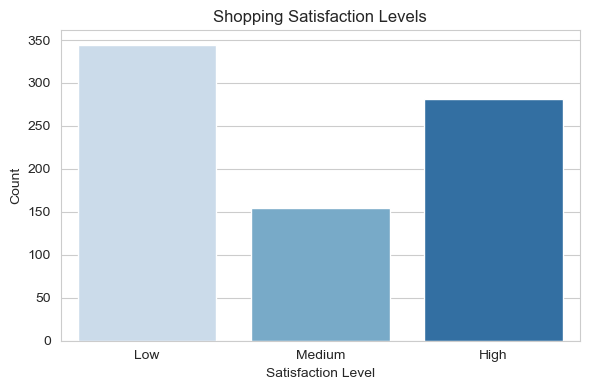

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Shopping_Satisfaction is numeric
df["Shopping_Satisfaction"] = pd.to_numeric(df["Shopping_Satisfaction"], errors="coerce")

# Create satisfaction groups
def label_satisfaction(x):
    if x <= 2:
        return "Low"
    elif x == 3:
        return "Medium"
    else:  # 4 or 5
        return "High"

df["Sat_Level"] = df["Shopping_Satisfaction"].apply(label_satisfaction)

# Count each group
sat_counts = df["Sat_Level"].value_counts().reindex(["Low", "Medium", "High"])

plt.figure(figsize=(6,4))
sns.barplot(x=sat_counts.index, y=sat_counts.values, palette="Blues")
plt.title("Shopping Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


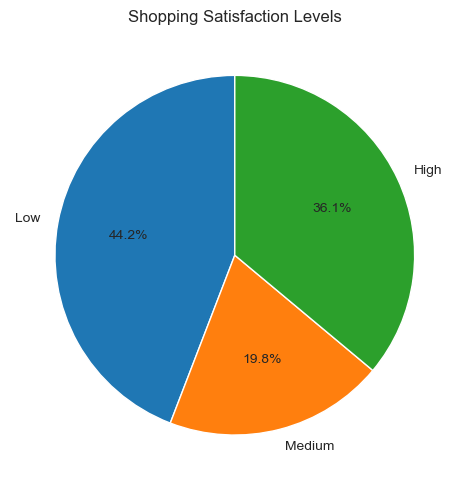

In [85]:
plt.figure(figsize=(5,5))
plt.pie(sat_counts.values, labels=sat_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Shopping Satisfaction Levels")
plt.tight_layout()
plt.show()


##  Correlation heatmap (for “Correlation between recommendation usefulness and satisfaction”)

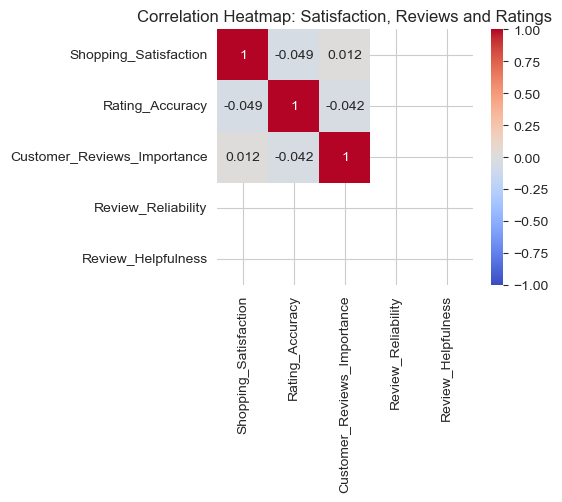

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure all variables are numeric
cols = [
    "Shopping_Satisfaction",
    "Rating_Accuracy",
    "Customer_Reviews_Importance",
    "Review_Reliability",
    "Review_Helpfulness",
]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Correlation matrix
corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap: Satisfaction, Reviews and Ratings")
plt.tight_layout()
plt.show()


## other charts already done in task 2 